# Qubit Experiments - Standardized Demo (NSWAVE)
This notebook is a Instruction set demo. All experiments are driven by the **NSWAVE control method** (not the AWG mode), covering the following experimental procedures. All timing parameters (pulse width / trigger period / delay) are kept identical to the original version:

1. Resonator Spectroscopy (S21 Sweep)
2. Qubit Spectroscopy (Two-Tone)
3. Flux-Dependent Qubit Spectroscopy
4. Power Rabi
5. Time Rabi (Rabi Oscillation)
6. T1 (Energy Relaxation)
7. T2* Ramsey (Free Induction Decay)
8. T2 Echo (Hahn Echo)
9. Feedback (Active Reset Demo)

**Usage order**: first run `0. Environment Setup` -> `1. Device Init & Sync`, after which any experiment cell can be executed independently.

## 0. Environment Setup

In [1]:
# import package
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.notebook import tqdm
import nsqdriver.nswave as nw
from nsqdriver import MCIDriver, QSYNCDriver
from nsqdriver.NS_MCI import SHARED_DEVICE_MEM
%matplotlib widget
plt.style.use('ggplot') 

### 0.1. Firmware Update (Optional)
Whenever the device is powered on, please execute the following code during the first run of the script.  
This code is used to switch the device mode and takes approximately 3 minutes to complete. Please be patient.  
The device will reboot during this process.  
The mode switch is considered complete once the code finishes executing and you can successfully reconnect to the device.

In [2]:
#power change firmwave version
SHARED_DEVICE_MEM.clear_ip()
UpdatedeviceIP = "192.168.110.224"
UpdatedeviceIP = "172.16.153.224"
driverUpdate = MCIDriver(UpdatedeviceIP)
driverUpdate.open(debug=True)
driverUpdate.set('FirmwareChange', [0,0,0], ["S2-O1","S13-O1","S12-O1"])

## 1. Device Init & Sync

In [4]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"
deviceIP = "172.16.153.224"
# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   2,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.224 opened successfully
*********设备172.16.153.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 9.2
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.224开启成功
System synchronization succeeded


In [5]:
# ---- Top-level Gaussian pulse helper (used by spectrum cell, etc.) ----
def generate_gaussian_pulse(freq, t, fs, delay=0, rise_time_ratio=0.15):
    """
    Generate a full Gaussian pulse (envelope is zero at both ends, no flat top).
    freq: carrier frequency (Hz)
    t:    total pulse duration (s)
    fs:   sample rate (Hz)
    delay, rise_time_ratio: reserved, unused
    """
    num_points = round(t * fs)
    time_line  = np.linspace(0, t, num_points, endpoint=False)
    center = t / 2
    std    = t / 6                  # ~99.7% energy within +/- 3 sigma
    envelope = np.exp(-0.5 * ((time_line - center) / std) ** 2)
    carrier  = np.sin(2 * np.pi * freq * time_line)
    return envelope * carrier

## 5. Resonator Spectroscopy (S21 Sweep)

In [6]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"
deviceIP = "172.16.153.224"
# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   2,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.224 opened successfully
*********设备172.16.153.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 9.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.224开启成功
System synchronization succeeded


S21 sweep:   0%|          | 0/51 [00:00<?, ?it/s]

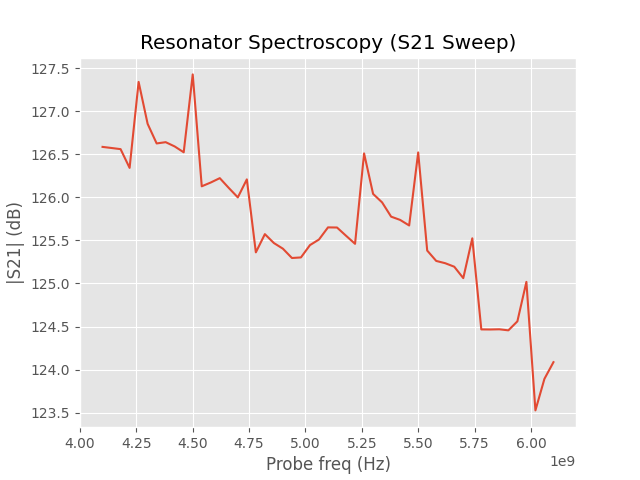

In [7]:
# ============================================================
# Resonator Spectroscopy (S21 Sweep)
# ============================================================

# ---- Hardware params ----
probe_out_ch = 'S2-O1'    # Readout probe output  (DA srate = 8 GS/s)
probe_in_ch  = 'S2-I1'    # Readout demod input   (AD srate = 4 GS/s)
probe_freq   = 5.1e9      # Resonator probe IF (sweep anchor)

# ---- Capture / shot params ----
shots          = 1024
trig_period    = 50e-6
cap_num        = 1

# ---- Pulse params ----
probe_width     = 2e-6
probe_in_delay  = 100e-9

# ---- Sweep range ----
probe_freq_list = np.linspace(probe_freq - 1e9, probe_freq + 1e9, 51)

# ---- nswave kernels ----
@nw.kernel
def program_probe_in(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param entry: [wait_time, capture_width, capture_delay, play_width]
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], 0, 0)

@nw.kernel
def program_probe_out(freq:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray = np.linspace(0, probe_width, int(probe_width * srate), endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

# ---- Device base setup ----
device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))

device.set('ProgramINSrc', program_probe_in([
    [probe_in_delay, probe_width, 0, 0],
] * cap_num), probe_in_ch)

# ---- Frequency sweep ----
s21_iq_list = []
for probe_freq in tqdm(probe_freq_list, desc='S21 sweep'):
    device.set('FreqList', [probe_freq], probe_in_ch)
    device.set('ProgramOUTSrc',
               program_probe_out(probe_freq, probe_width),
               probe_out_ch)
    device.set('StartCapture')
    qsync.set('GenerateTrig', trig_period)
    data = device.get('IQ', probe_in_ch, round(shots * cap_num))
    cap1 = data[0, 0::cap_num]
    s21_iq_list.append(cap1)

# ---- Data processing and plotting ----
s21_iq_arr  = np.array(s21_iq_list)              # (n_freq, shots)
s21_complex = s21_iq_arr.mean(axis=1)            # (n_freq,)
s21_db      = 20 * np.log10(np.abs(s21_complex))

plt.figure()
plt.plot(probe_freq_list, s21_db)
plt.xlabel('Probe freq (Hz)')
plt.ylabel('|S21| (dB)')
plt.title('Resonator Spectroscopy (S21 Sweep)')
plt.show()

## 6. Qubit Spectroscopy (Two-Tone)

In [8]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"
deviceIP = "172.16.153.224"
# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.224 opened successfully
*********设备172.16.153.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 9.2
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.224开启成功
System synchronization succeeded


Qubit Spectroscopy:   0%|          | 0/101 [00:00<?, ?it/s]

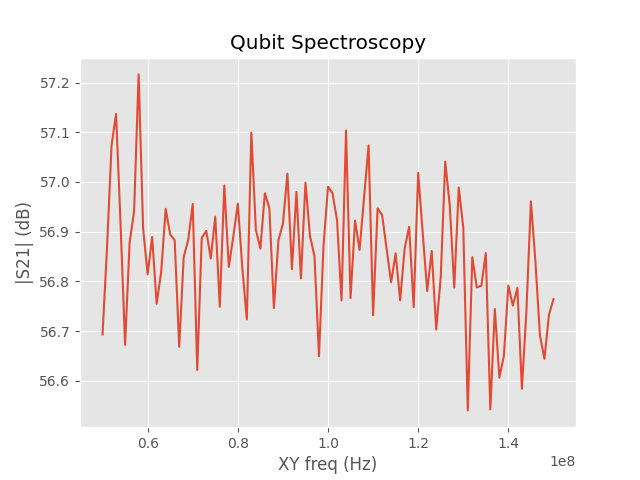

In [14]:
# ============================================================
# Qubit Spectroscopy (XY frequency sweep, fixed long XY pulse)
# ============================================================

# ---- Hardware params ----
xy_ch        = 'S13-O1'   # XY drive output       (DA srate = 8 GS/s)
probe_out_ch = 'S2-O1'    # Readout probe output  (DA srate = 8 GS/s)
probe_in_ch  = 'S2-I1'    # Readout demod input   (AD srate = 4 GS/s)
xy_freq      = 0.1e9      # Qubit drive IF (sweep anchor)
probe_freq   = 0.1e9      # Resonator probe IF

# ---- Capture / shot params ----
shots          = 1024
trig_period    = 500e-6
cap_num        = 1

# ---- Pulse params ----
demod_freq_list = [probe_freq + i * 0 for i in range(8)]      # demod tones
probe_out_delay = 400e-9                                      # probe-in to capture delay
probe_width     = 2e-6
probe_in_delay  = 100e-9                                      # XY end to probe-out delay
drive_width     = 1e-6                                        # XY Gaussian pulse width (actually played)
xy_margin       = 0.1e-6                                      # buffer between XY end and readout start
drive_window    = drive_width + xy_margin                     # readout-wait window probe/cap must hold

# ---- Sweep range ----
xy_freq_list = np.linspace(xy_freq - 50e6, xy_freq + 50e6, 101)

# ---- nswave kernels ----
@nw.kernel
def program_probe_in(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param entry: [wait_time, capture_width, capture_delay, play_width]
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], i[2], i[3])

@nw.kernel
def program_probe_out(freq:nw.Var, drive_window:nw.Var, probe_in_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray = np.linspace(0, probe_width, int(probe_width * srate), endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_window)
    nw.wait(probe_in_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var):
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

# ---- Device base setup ----
device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))
device.set('FreqList', demod_freq_list, probe_in_ch)
device.set('Output', 1, xy_ch)

device.set('ProgramINSrc', program_probe_in([
    [drive_window + probe_out_delay + probe_in_delay, probe_width, 0, 0],
] * cap_num), probe_in_ch)

# ---- Frequency sweep ----
spectrum_iq_list = []
for xy_freq in tqdm(xy_freq_list, desc='Qubit Spectroscopy'):
    device.set('ProgramOUTSrc',
               program_probe_out(probe_freq, drive_window, probe_in_delay, probe_width),
               probe_out_ch)
    device.set('ProgramOUTSrc',
               program_drive(xy_freq, amp=1,
                             envelope=generate_gaussian_pulse(xy_freq, drive_width, da_rate_xy)),
               xy_ch)
    device.set('StartCapture')
    qsync.set('GenerateTrig', trig_period)
    data = device.get('IQ', probe_in_ch, round(shots * cap_num))
    cap1 = data[:, 0::cap_num]
    spectrum_iq_list.append(cap1)

# ---- Data processing and plotting ----
spectrum_iq_arr  = np.array(spectrum_iq_list)            # (sweep, n_demod, shots)
spectrum_complex = spectrum_iq_arr.mean(axis=2)          # (sweep, n_demod)
spectrum_db      = 20 * np.log10(np.abs(spectrum_complex))

plt.figure()
plt.plot(xy_freq_list, spectrum_db[:, 0])
plt.xlabel('XY freq (Hz)')
plt.ylabel('|S21| (dB)')
plt.title('Qubit Spectroscopy')
plt.show()

## 7. Flux-Dependent Qubit Spectroscopy

2D sweep: outer loop scans Z bias (flux), inner loop scans XY frequency. Plotting the 2D flux spectrum reveals how the qubit transition frequency changes topologically with flux.

In [17]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"
deviceIP = "172.16.153.224"
# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.224 opened successfully
*********设备172.16.153.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 8.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.224开启成功
System synchronization succeeded


Qubit Spectroscopy:   0%|          | 0/11 [00:00<?, ?it/s]

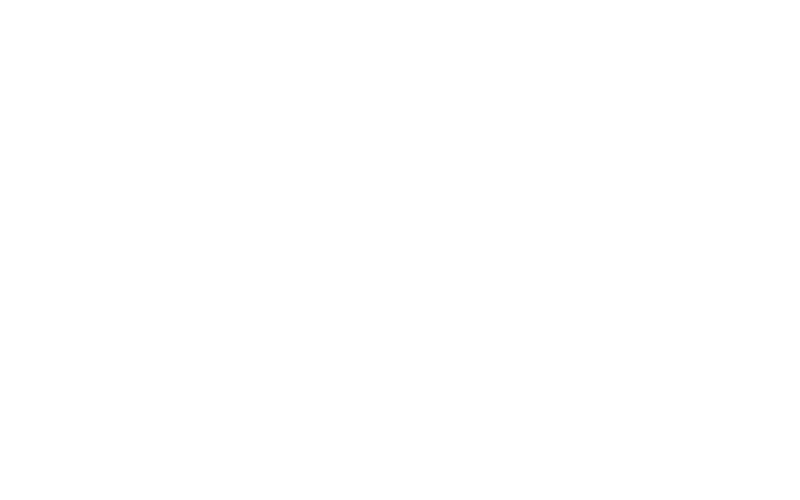

In [16]:
# ============================================================
# Qubit Spectroscopy (XY frequency sweep, fixed long XY pulse)
# ============================================================

# ---- Hardware params ----
xy_ch        = 'S13-O1'   # XY drive output       (DA srate = 8 GS/s)
probe_out_ch = 'S2-O1'    # Readout probe output  (DA srate = 8 GS/s)
probe_in_ch  = 'S2-I1'    # Readout demod input   (AD srate = 4 GS/s)
z_ch         = 'S12-O1'   # z bias output         (DA srate = 4 GS/s)
xy_freq      = 0.01e9      # Qubit drive IF (sweep anchor)
probe_freq   = 0.1e9      # Resonator probe IF

# ---- Capture / shot params ----
shots          = 1024
trig_period    = 500e-6
cap_num        = 1

# ---- Pulse params ----
demod_freq_list = [probe_freq + i * 0 for i in range(8)]      # demod tones
probe_out_delay = 400e-9
probe_width     = 2e-6
probe_in_delay  = 100e-9
drive_width     = 1e-6                                        # XY Gaussian pulse width (actually played)
xy_margin       = 0.1e-6                                      # buffer between XY end and readout start
drive_window    = drive_width + xy_margin                     # readout-wait window probe/cap must hold

# ---- Sweep range ----
xy_freq_list = np.linspace(xy_freq - 5e6, xy_freq + 5e6, 11)
bias_list    = np.linspace(-1, 1, 11)

# ---- Z bias config ----
z_width = drive_window                                        # Z spans the full XY drive window

# ---- nswave kernels ----
@nw.kernel
def program_probe_in(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    # param entry: [wait_time, capture_width, capture_delay, play_width]
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], i[2], i[3])

@nw.kernel
def program_probe_out(freq:nw.Var, drive_window:nw.Var, probe_in_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray = np.linspace(0, probe_width, int(probe_width * srate), endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_window)
    nw.wait(probe_in_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var, xy_margin: nw.Var):
    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(xy_margin)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_z(envelope: nw.Var):
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

# ---- Device base setup ----
device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))
device.set('FreqList', demod_freq_list, probe_in_ch)
device.set('Output', 1, xy_ch)
device.set('Output', 1, z_ch)


device.set('ProgramINSrc', program_probe_in([
    [drive_window + probe_out_delay + probe_in_delay, probe_width, 0, 0],
] * cap_num), probe_in_ch)

device.set('ProgramOUTSrc',
           program_probe_out(probe_freq, drive_window, probe_in_delay, probe_width),
           probe_out_ch)

# ---- Frequency and bias sweep ----
spectrum_2d = []
for xy_freq in tqdm(xy_freq_list, desc='Qubit Spectroscopy'):
    device.set('ProgramOUTSrc',
               program_drive(xy_freq, amp=1,
                             envelope=generate_gaussian_pulse(xy_freq, drive_width, da_rate_xy),
                             xy_margin=xy_margin),
               xy_ch)
    spectrum_row = []
    for bias in bias_list:
        z_envelope = bias * np.ones(round(z_width * da_rate_z))
        device.set('ProgramOUTSrc', program_z(envelope=z_envelope), z_ch)
        device.set('StartCapture')
        qsync.set('GenerateTrig', trig_period)
        data = device.get('IQ', probe_in_ch, round(shots * cap_num))
        cap1 = data[:, 0::cap_num]
        spectrum_row.append(cap1)
    spectrum_2d.append(spectrum_row)

# ---------- 5. Data processing and plotting ----------
spectrum_2d_arr     = np.array(spectrum_2d)                           # (n_freq, n_bias, n_demod, shots)
spectrum_2d_complex = spectrum_2d_arr.mean(axis=3)                    # (n_freq, n_bias, n_demod)
spectrum_2d_db      = 20 * np.log10(np.abs(spectrum_2d_complex))

plt.figure(figsize=(8, 5))
plt.pcolormesh(xy_freq_list / 1e6, bias_list, spectrum_2d_db[:, :, 0].T,
               shading="auto", cmap="viridis")
plt.colorbar(label="|S21| (dB)")
plt.xlabel("XY Drive Frequency (MHz)")
plt.ylabel("Z Bias (V)")
plt.title("Qubit Spectrum vs Flux")
plt.tight_layout()
plt.show()

## 8. Power Rabi

In [18]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"
deviceIP = "172.16.153.224"
# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.224 opened successfully
*********设备172.16.153.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 8.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.224开启成功
System synchronization succeeded


Power Rabi:   0%|          | 0/11 [00:00<?, ?it/s]

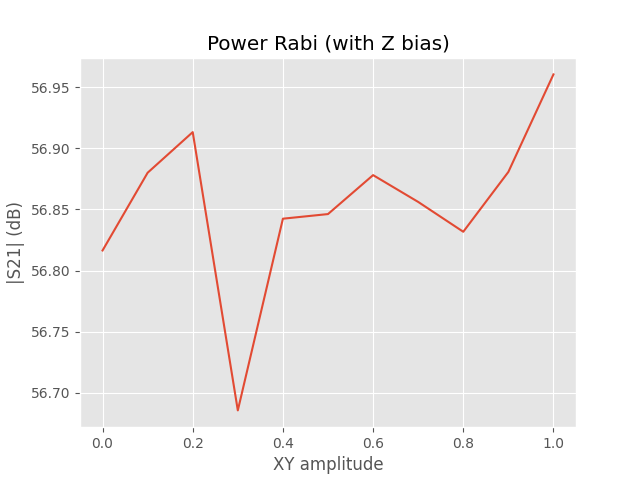

In [19]:
# ============================================================
# Power Rabi (with Z flux bias enveloping XY)
# ============================================================
# Sweep the XY drive amplitude at a fixed pulse width to map the
# Rabi oscillation. A constant Z flux bias (S12-O1, 2 GS/s) is played
# alongside; Z is widened by `z_margin` on both sides so it always
# completely envelops the XY drive even with hardware skew.

# ---- Hardware params ----
xy_ch        = 'S13-O1'   # XY drive output       (DA srate = 8 GS/s)
probe_out_ch = 'S2-O1'    # Readout probe output  (DA srate = 8 GS/s)
probe_in_ch  = 'S2-I1'    # Readout demod input   (AD srate = 4 GS/s)
z_ch         = 'S12-O1'   # Z flux bias output    (DA srate = 2 GS/s)-
xy_freq      = 0.1e9      # Qubit drive IF
probe_freq   = 0.1e9      # Resonator probe IF

# ---- Capture / shot params ----
shots          = 1024
trig_period    = 800e-6
cap_num        = 1

# ---- Pulse params ----
demod_freq_list = [probe_freq + i * 0 for i in range(8)]
probe_out_delay = 300e-9
probe_width     = 2e-6
probe_in_delay  = 220e-9
drive_width     = 0.4e-6                                    # XY pulse width

# ---- Sweep range ----
xy_amp_list     = np.linspace(0, 1, 11)                      # XY amplitude scan

# ---- Z bias config (S12-O1, 2 GS/s) ----
z_amp           = 1                                       # constant Z bias amplitude
z_margin        = 96e-9                                      # margin before/after XY (>= 16 ns)
z_width         = drive_width + 2 * z_margin                 # total Z pulse width

# ---- Local Gaussian envelope (cos carrier, with amp scaling) ----
def generate_gaussian_envelope(freq, t, fs, delay=0, amp=1):
    num_points = round(t * fs)
    time_line  = np.linspace(0, t, num_points, endpoint=False)
    gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
    std_sq2 = t / (6 * np.sqrt(np.log(2)))
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
    carrier  = np.cos(2 * np.pi * freq * time_line)
    return envelope * carrier * amp

# ---- nswave kernels ----
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], 0, 0)

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, probe_in_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray = np.linspace(0, probe_width, int(probe_width * srate), endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(probe_in_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var, z_margin:nw.Var):
    frame_0: nw.Frame = nw.init_frame(freq, 0)
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(z_margin)        # let Z bias settle so Z fully envelops XY
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_z(envelope: nw.Var):
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

# ---- Device base setup ----
device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))
device.set('FreqList', demod_freq_list, probe_in_ch)


# ---- Constant playbacks: probe + Z bias (don't change inside the sweep) ----
z_envelope = z_amp * np.ones(round(z_width * da_rate_z))
device.set('ProgramOUTSrc', program_z(envelope=z_envelope), z_ch)

# Probe output and capture window are aligned to the END of the Z pulse,
# i.e. they have to wait the full z_width (= drive_width + 2 * z_margin).
device.set('ProgramINSrc', program_cap([
    [z_width + probe_out_delay + probe_in_delay, probe_width, 0, 0],
] * cap_num), probe_in_ch)
device.set('ProgramOUTSrc',
           program_probe_out(probe_freq, z_width, probe_in_delay, probe_width),
           probe_out_ch)

# ---- Amplitude sweep ----
rabi_iq_list = []
for xy_amp in tqdm(xy_amp_list, desc='Power Rabi'):
    xy_envelope = generate_gaussian_envelope(0, drive_width, da_rate_xy, 0, xy_amp)
    device.set('ProgramOUTSrc',
               program_drive(xy_freq, amp=1, envelope=xy_envelope, z_margin=z_margin),
               xy_ch)
    device.set('StartCapture')
    qsync.set('GenerateTrig', trig_period)
    data = device.get('IQ', probe_in_ch, round(shots * cap_num))
    cap1 = data[:, 0::cap_num]
    rabi_iq_list.append(cap1)

# ---- Data processing and plotting ----
rabi_iq_arr  = np.array(rabi_iq_list)            # (sweep, n_demod, shots)
rabi_complex = rabi_iq_arr.mean(axis=2)          # (sweep, n_demod)
rabi_db      = 20 * np.log10(np.abs(rabi_complex))

plt.figure()
plt.plot(xy_amp_list, rabi_db[:, 0])
plt.xlabel('XY amplitude')
plt.ylabel('|S21| (dB)')
plt.title('Power Rabi (with Z bias)')
plt.show()

## 9. Time Rabi (Rabi Oscillation)

In [20]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"
deviceIP = "172.16.153.224"
# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.224 opened successfully
*********设备172.16.153.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 8.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.224开启成功
System synchronization succeeded


Time Rabi:   0%|          | 0/47 [00:00<?, ?it/s]

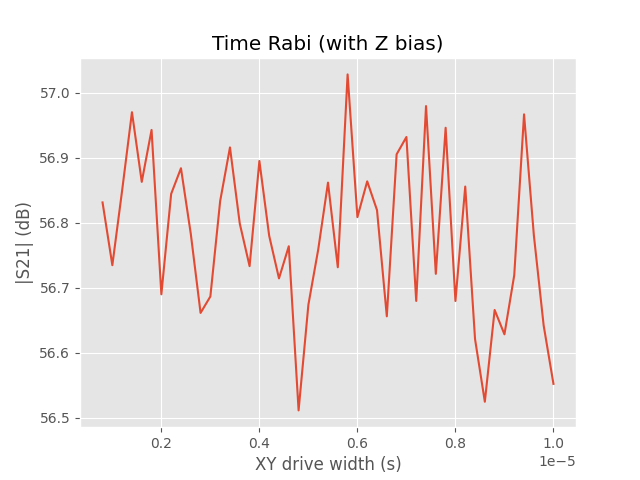

In [23]:
# ============================================================
# Time Rabi (with Z flux bias enveloping XY)
# ============================================================
# Sweep the XY drive width at a fixed amplitude. A constant Z flux bias
# (S12-O1, 2 GS/s) is widened by `z_margin` on both sides so it always
# completely envelops the XY drive even with hardware skew.
# Z must be reprogrammed each iteration because z_width tracks xy_width.

# ---- Hardware params ----
xy_ch        = 'S13-O1'   # XY drive output       (DA srate = 8 GS/s)
probe_out_ch = 'S2-O1'    # Readout probe output  (DA srate = 8 GS/s)
probe_in_ch  = 'S2-I1'    # Readout demod input   (AD srate = 4 GS/s)
z_ch         = 'S12-O1'   # Z flux bias output    (DA srate = 2 GS/s)-
xy_freq      = 0.1e9      # Qubit drive IF
probe_freq   = 0.1e9      # Resonator probe IF

# ---- Capture / shot params ----
shots          = 1024
trig_period    = 800e-6
cap_num        = 1
reps           = 1                                           # number of XY pulse repetitions per shot

# ---- Pulse params ----
demod_freq_list = [probe_freq + i * 0 for i in range(8)]
probe_out_delay = 300e-9
probe_width     = 2e-6
probe_in_delay  = 220e-9                                     # spacing between Z end and probe start
xy_amp          = 0.82                                       # XY drive amplitude

# ---- Sweep range ----
drive_width_list = np.arange(4, 51, 1) * 200e-9               # XY pulse width scan

# ---- Z bias config (S12-O1, 2 GS/s) ----
z_amp           = 1                                          # constant Z bias amplitude
z_margin        = 96e-9                                      # margin before/after XY (>= 16 ns)

# ---- Local Gaussian envelope (cos carrier, with amp scaling) ----
def generate_gaussian_envelope(freq, t, fs, delay=0, amp=1):
    num_points = round(t * fs)
    time_line  = np.linspace(0, t, num_points, endpoint=False)
    gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
    std_sq2 = t / (6 * np.sqrt(np.log(2)))
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
    carrier  = np.cos(2 * np.pi * freq * time_line)
    return envelope * carrier * amp

# ---- nswave kernels ----
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], 0, 0)

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, probe_in_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray = np.linspace(0, probe_width, int(probe_width * srate), endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(probe_in_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var, z_margin:nw.Var):
    frame_0: nw.Frame = nw.init_frame(freq, 0)
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(z_margin)        # let Z bias settle so Z fully envelops XY
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_z(envelope: nw.Var):
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

# ---- Device base setup ----
device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))
device.set('FreqList', demod_freq_list, probe_in_ch)

# ---- Width sweep (Z width = xy_width*reps + 2*z_margin per iter) ----
rabi_iq_list = []
for xy_width in tqdm(drive_width_list, desc='Time Rabi'):
    xy_total = xy_width * reps                               # XY active duration
    z_width  = xy_total + 2 * z_margin                       # Z fully envelops XY

    z_envelope = z_amp * np.ones(round(z_width * da_rate_z))
    device.set('ProgramOUTSrc', program_z(envelope=z_envelope), z_ch)

    device.set('ProgramINSrc', program_cap([
        [z_width + probe_out_delay + probe_in_delay, probe_width, 0, 0],
    ] * cap_num), probe_in_ch)
    device.set('ProgramOUTSrc',
               program_probe_out(probe_freq, z_width, probe_in_delay, probe_width),
               probe_out_ch)

    xy_envelope = generate_gaussian_envelope(0, xy_width, da_rate_xy, 0, xy_amp)
    device.set('ProgramOUTSrc',
               program_drive(xy_freq, amp=1, envelope=xy_envelope, z_margin=z_margin),
               xy_ch)
    device.set('StartCapture')
    qsync.set('GenerateTrig', trig_period)
    data = device.get('IQ', probe_in_ch, round(shots * cap_num))
    cap1 = data[:, 0::cap_num]
    rabi_iq_list.append(cap1)

# ---- Data processing and plotting ----
rabi_iq_arr  = np.array(rabi_iq_list)            # (sweep, n_demod, shots)
rabi_complex = rabi_iq_arr.mean(axis=2)          # (sweep, n_demod)
rabi_db      = 20 * np.log10(np.abs(rabi_complex))

plt.figure()
plt.plot(drive_width_list * reps, rabi_db[:, 0])
plt.xlabel('XY drive width (s)')
plt.ylabel('|S21| (dB)')
plt.title('Time Rabi (with Z bias)')
plt.show()

## 10. T1 (Energy Relaxation)

In [24]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"
deviceIP = "172.16.153.224"
# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.224 opened successfully
*********设备172.16.153.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 8.4
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.224开启成功
System synchronization succeeded


T1:   0%|          | 0/50 [00:00<?, ?it/s]

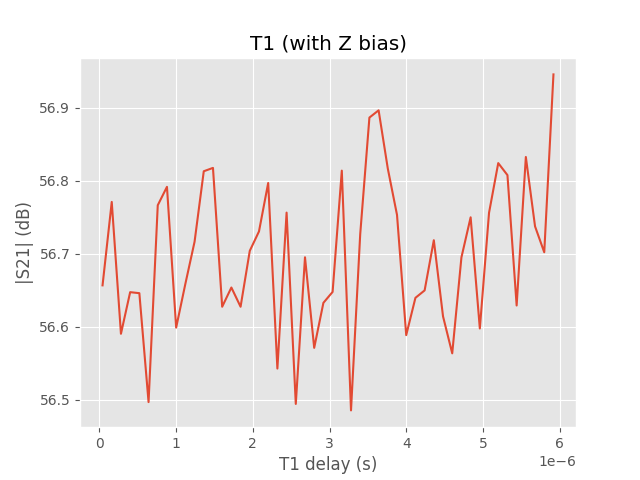

In [25]:
# ============================================================
# T1 (with Z flux bias enveloping XY pi-pulse only)
# ============================================================
# pi-pulse, then sweep delay before readout. Z bias (S12-O1, 2 GS/s)
# only envelops the XY pi-pulse (with `z_margin` buffer on both sides).
# After Z ends, the qubit relaxes for `t1_delay` (no Z, no XY), then
# `probe_in_delay` spacing, then probe.

# ---- Hardware params ----
xy_ch        = 'S13-O1'   # XY drive output       (DA srate = 8 GS/s)
probe_out_ch = 'S2-O1'    # Readout probe output  (DA srate = 8 GS/s)
probe_in_ch  = 'S2-I1'    # Readout demod input   (AD srate = 4 GS/s)
z_ch         = 'S12-O1'   # Z flux bias output    (DA srate = 2 GS/s)-
xy_freq      = 0.1e9      # Qubit drive IF
probe_freq   = 0.1e9      # Resonator probe IF

# ---- Capture / shot params ----
shots          = 1024
trig_period    = 1200e-6
cap_num        = 1

# ---- Pulse params ----
demod_freq_list = [probe_freq + i * 0 for i in range(8)]
probe_out_delay = 300e-9
probe_width     = 2e-6
probe_in_delay  = 220e-9                                     # spacing between Z end and probe start
drive_width     = 0.4e-6                                     # XY pi-pulse slot width (actual pulse = drive_width/2)
xy_amp          = 0.46                                       # XY pi-pulse amplitude

# ---- Sweep range ----
t1_delay_list   = np.arange(1, 151, 3) * 40e-9               # delay between pi pulse and readout

# ---- Z bias config (S12-O1, 2 GS/s) ----
z_amp           = 1                                        # constant Z bias amplitude
z_margin        = 96e-9                                      # margin before/after qubit-active span (>= 16 ns)

# ---- Local Gaussian envelope (cos carrier, with amp scaling) ----
def generate_gaussian_envelope(freq, t, fs, delay=0, amp=1):
    num_points = round(t * fs)
    time_line  = np.linspace(0, t, num_points, endpoint=False)
    gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
    std_sq2 = t / (6 * np.sqrt(np.log(2)))
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
    carrier  = np.cos(2 * np.pi * freq * time_line)
    return envelope * carrier * amp

# ---- nswave kernels ----
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], 0, 0)

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, probe_in_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray = np.linspace(0, probe_width, int(probe_width * srate), endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(probe_in_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var, z_margin:nw.Var):
    frame_0: nw.Frame = nw.init_frame(freq, 0)
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(z_margin)        # let Z bias settle so Z fully envelops XY
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_z(envelope: nw.Var):
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

# ---- Device base setup ----
device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))
device.set('FreqList', demod_freq_list, probe_in_ch)

# ---- Z bias and XY pi-pulse stay the same across the sweep ----
# Z only covers the XY pi-pulse slot, NOT the relaxation t1_delay.
z_width    = drive_width + 2 * z_margin                      # Z covers pi-pulse only
z_envelope = z_amp * np.ones(round(z_width * da_rate_z))
device.set('ProgramOUTSrc', program_z(envelope=z_envelope), z_ch)

xy_envelope = generate_gaussian_envelope(0, drive_width, da_rate_xy, 0, xy_amp)
device.set('ProgramOUTSrc',
           program_drive(xy_freq, amp=1, envelope=xy_envelope, z_margin=z_margin),
           xy_ch)

# ---- T1 delay sweep (only probe / cap timing depends on t1_delay) ----
t1_iq_list = []
for t1_delay in tqdm(t1_delay_list, desc='T1'):
    device.set('ProgramINSrc', program_cap([
        [z_width + t1_delay + probe_out_delay + probe_in_delay, probe_width, 0, 0],
    ] * cap_num), probe_in_ch)
    device.set('ProgramOUTSrc',
               program_probe_out(probe_freq, z_width + t1_delay, probe_in_delay, probe_width),
               probe_out_ch)
    device.set('StartCapture')
    qsync.set('GenerateTrig', trig_period)
    data = device.get('IQ', probe_in_ch, round(shots * cap_num))
    cap1 = data[:, 0::cap_num]
    t1_iq_list.append(cap1)

# ---- Data processing and plotting ----
t1_iq_arr  = np.array(t1_iq_list)              # (sweep, n_demod, shots)
t1_complex = t1_iq_arr.mean(axis=2)            # (sweep, n_demod)
t1_db      = 20 * np.log10(np.abs(t1_complex))

plt.figure()
plt.plot(t1_delay_list, t1_db[:, 0])
plt.xlabel('T1 delay (s)')
plt.ylabel('|S21| (dB)')
plt.title('T1 (with Z bias)')
plt.show()

## 11. T2* Ramsey (Free Induction Decay)

In [26]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"
deviceIP = "172.16.153.224"
# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.224 opened successfully
*********设备172.16.153.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 8.3
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.224开启成功
System synchronization succeeded


T2 Ramsey:   0%|          | 0/100 [00:00<?, ?it/s]

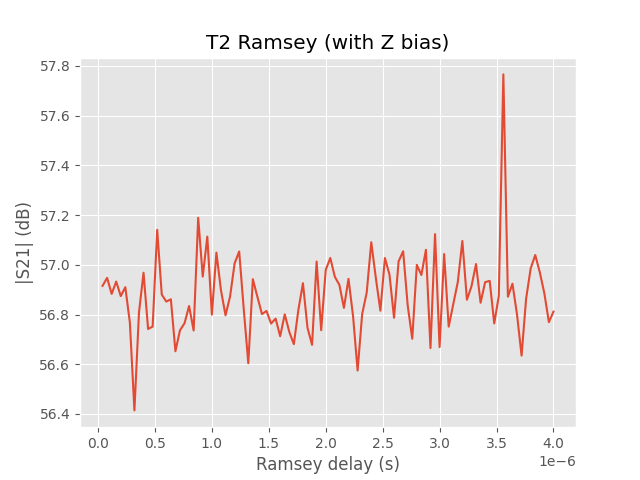

In [29]:
# ============================================================
# T2 Ramsey (with Z flux bias enveloping the whole pi/2 - tau - pi/2 span)
# ============================================================
# pi/2 - tau - pi/2 with intentional detuning. Z bias (S12-O1, 2 GS/s)
# fully envelops the entire qubit-active span (= drive_width + ramsey_delay)
# with `z_margin` buffer on both sides. Z must be reprogrammed each iter
# because z_width tracks ramsey_delay.

# ---- Hardware params ----
xy_ch        = 'S13-O1'   # XY drive output       (DA srate = 8 GS/s)
probe_out_ch = 'S2-O1'    # Readout probe output  (DA srate = 8 GS/s)
probe_in_ch  = 'S2-I1'    # Readout demod input   (AD srate = 4 GS/s)
z_ch         = 'S12-O1'   # Z flux bias output    (DA srate = 2 GS/s)-
xy_freq      = 0.1e9      # Qubit drive IF
probe_freq   = 0.1e9      # Resonator probe IF

# ---- Capture / shot params ----
shots          = 1024
trig_period    = 1200e-6
cap_num        = 1

# ---- Pulse params ----
detu            = 0.01e6                                     # intentional XY detuning
xy_freq_d       = xy_freq + detu                             # detuned XY carrier
demod_freq_list = [probe_freq + i * 0 for i in range(8)]
probe_out_delay = 300e-9
probe_width     = 2e-6
probe_in_delay  = 220e-9                                     # spacing between Z end and probe start
drive_width     = 0.4e-6                                     # full pi-pulse width (each pi/2 uses drive_width/2)
xy_amp          = 0.82                                       # XY pi/2 amplitude

# ---- Sweep range ----
ramsey_delay_list = np.arange(1, 101, 1) * 40e-9         # delay between the two pi/2 pulses

# ---- Z bias config (S12-O1, 2 GS/s) ----
z_amp           = 1                                        # constant Z bias amplitude
z_margin        = 96e-9                                      # margin before/after qubit-active span (>= 16 ns)

# ---- Local Gaussian envelope (cos carrier, with amp scaling) ----
def generate_gaussian_envelope(freq, t, fs, delay=0, amp=1):
    num_points = round(t * fs)
    time_line  = np.linspace(0, t, num_points, endpoint=False)
    gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
    std_sq2 = t / (6 * np.sqrt(np.log(2)))
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
    carrier  = np.cos(2 * np.pi * freq * time_line)
    return envelope * carrier * amp

# ---- nswave kernels ----
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], i[2], i[3])

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, probe_in_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray = np.linspace(0, probe_width, int(probe_width * srate), endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(probe_in_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var, z_margin:nw.Var, ramsey_delay: nw.Var):
    frame_0: nw.Frame = nw.init_frame(freq, 0)
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(z_margin)        # let Z bias settle so Z fully envelops XY
    nw.play_wave(envelope_1, 1, 0, 0)
    nw.wait(ramsey_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_z(envelope: nw.Var):
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

# ---- Device base setup ----
device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))
device.set('FreqList', demod_freq_list, probe_in_ch)

half_drive_width = drive_width / 2
xy_envelope      = generate_gaussian_envelope(0, half_drive_width, da_rate_xy, 0, xy_amp)

# ---- Ramsey delay sweep (Z width = drive_width + ramsey_delay + 2*z_margin per iter) ----
t2_iq_list = []
for ramsey_delay in tqdm(ramsey_delay_list, desc='T2 Ramsey'):
    qubit_active = half_drive_width * 2 + ramsey_delay       # pi/2 + tau + pi/2
    z_width      = qubit_active + 2 * z_margin               # Z fully envelops it

    z_envelope = z_amp * np.ones(round(z_width * da_rate_z))
    device.set('ProgramOUTSrc', program_z(envelope=z_envelope), z_ch)

    device.set('ProgramOUTSrc',
               program_drive(xy_freq_d, xy_amp, envelope=xy_envelope,
                             z_margin=z_margin, ramsey_delay=ramsey_delay),
               xy_ch)
    device.set('ProgramINSrc', program_cap([
        [z_width + probe_out_delay + probe_in_delay, probe_width, 0, 0],
    ] * cap_num), probe_in_ch)
    device.set('ProgramOUTSrc',
               program_probe_out(probe_freq, z_width, probe_in_delay, probe_width),
               probe_out_ch)
    device.set('StartCapture')
    qsync.set('GenerateTrig', trig_period)
    data = device.get('IQ', probe_in_ch, round(shots * cap_num))
    cap1 = data[:, 0::cap_num]
    t2_iq_list.append(cap1)

# ---- Data processing and plotting ----
t2_iq_arr  = np.array(t2_iq_list)              # (sweep, n_demod, shots)
t2_complex = t2_iq_arr.mean(axis=2)            # (sweep, n_demod)
t2_db      = 20 * np.log10(np.abs(t2_complex))

plt.figure()
plt.plot(ramsey_delay_list, t2_db[:, 0])
plt.xlabel('Ramsey delay (s)')
plt.ylabel('|S21| (dB)')
plt.title('T2 Ramsey (with Z bias)')
plt.show()

## 12. T2 Echo (Hahn Echo)

In [30]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"
deviceIP = "172.16.153.224"
# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.224 opened successfully
*********设备172.16.153.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 8.7
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.224开启成功
System synchronization succeeded


T2 ECHO:   0%|          | 0/72 [00:00<?, ?it/s]

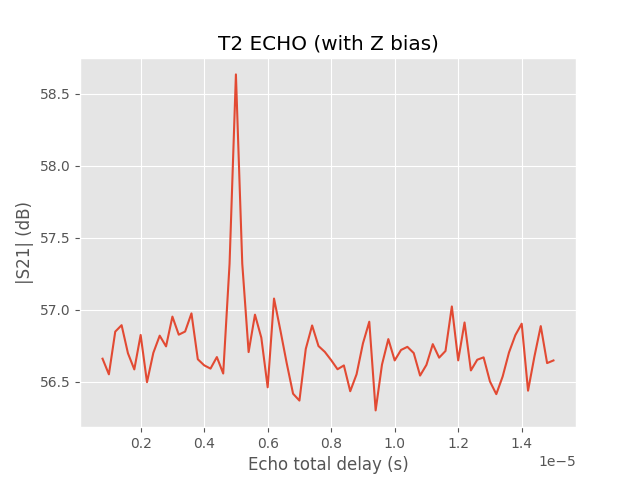

In [32]:
# ============================================================
# T2 ECHO (with Z flux bias enveloping the whole pi/2 - tau - pi - tau - pi/2 span)
# ============================================================
# Single-refocus echo. Z bias (S12-O1, 2 GS/s) fully envelops the whole
# qubit-active span (= 2*drive_width + 2*echo_delay) with `z_margin`
# buffer on both sides. Z must be reprogrammed each iter because z_width
# tracks echo_delay.

# ---- Hardware params ----
xy_ch        = 'S13-O1'   # XY drive output       (DA srate = 8 GS/s)
probe_out_ch = 'S2-O1'    # Readout probe output  (DA srate = 8 GS/s)
probe_in_ch  = 'S2-I1'    # Readout demod input   (AD srate = 4 GS/s)
z_ch         = 'S12-O1'   # Z flux bias output    (DA srate = 2 GS/s)-
xy_freq      = 0.1e9      # Qubit drive IF
probe_freq   = 0.1e9      # Resonator probe IF

# ---- Capture / shot params ----
shots          = 1024
trig_period    = 1200e-6
cap_num        = 1

# ---- Pulse params ----
detu            = 0.030e6                                    # intentional XY detuning
xy_freq_d       = xy_freq + detu                             # detuned XY carrier
demod_freq_list = [probe_freq + i * 0 for i in range(8)]
probe_out_delay = 300e-9
probe_width     = 2e-6
probe_in_delay  = 220e-9                                     # spacing between Z end and probe start
drive_width     = 0.4e-6                                     # full pi-pulse width (each pi/2 uses drive_width/2)
xy_amp          = 0.82                                       # XY pi/2 amplitude

# ---- Sweep range ----
echo_delay_list = np.arange(1, 19, 0.25) * 0.4e-6              # half-echo delay (full echo = 2 * echo_delay)

# ---- Z bias config (S12-O1, 2 GS/s) ----
z_amp           = 1                                          # constant Z bias amplitude
z_margin        = 96e-9                                      # margin before/after qubit-active span (>= 16 ns)

# ---- Local Gaussian envelope (cos carrier, with amp scaling) ----
def generate_gaussian_envelope(freq, t, fs, delay=0, amp=1):
    num_points = round(t * fs)
    time_line  = np.linspace(0, t, num_points, endpoint=False)
    gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
    std_sq2 = t / (4 * np.sqrt(np.log(2)))
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
    carrier  = np.cos(2 * np.pi * freq * time_line)
    return envelope * carrier * amp

# ---- nswave kernels ----
@nw.kernel
def program_cap(param: nw.Var):
    nw.wait_for_trigger()
    i: nw.Var
    for i in param:
        nw.wait(i[0])
        nw.capture(i[1], 0, 0)

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, probe_in_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray = np.linspace(0, probe_width, int(probe_width * srate), endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(probe_in_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_drive(freq:nw.Var, amp:nw.Var, envelope:nw.Var, z_margin:nw.Var, echo_delay: nw.Var):
    # Echo sequence: pi/2 - tau - (pi as 2x pi/2) - tau - pi/2
    frame_0: nw.Frame = nw.init_frame(freq, 0)
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(z_margin)        # let Z bias settle so Z fully envelops XY
    nw.play_wave(envelope_1, 1, 0, 0)
    nw.wait(echo_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    nw.play_wave(envelope_1, 1, 0, 0)
    nw.wait(echo_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

@nw.kernel
def program_z(envelope: nw.Var):
    envelope_1: nw.Envelope = nw.ins_envelope(envelope)
    nw.wait_for_trigger()
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

# ---- Device base setup ----
device.set("CaptureMode", 0)
device.set('Shot', int(shots))
qsync.set('Shot', int(shots))
device.set('FreqList', demod_freq_list, probe_in_ch)

half_drive_width = drive_width / 2
xy_envelope      = generate_gaussian_envelope(0, half_drive_width, da_rate_xy, 0, xy_amp)

# ---- Echo delay sweep (Z width = 2*drive_width + 2*echo_delay + 2*z_margin per iter) ----
t2_iq_list = []
for echo_delay in tqdm(echo_delay_list, desc='T2 ECHO'):
    qubit_active = half_drive_width * 4 + echo_delay * 2     # 4*pi/2 + 2*tau
    z_width      = qubit_active + 2 * z_margin               # Z fully envelops it

    z_envelope = z_amp * np.ones(round(z_width * da_rate_z))
    device.set('ProgramOUTSrc', program_z(envelope=z_envelope), z_ch)

    device.set('ProgramOUTSrc',
               program_drive(xy_freq_d, xy_amp, envelope=xy_envelope,
                             z_margin=z_margin, echo_delay=echo_delay),
               xy_ch)
    device.set('ProgramINSrc', program_cap([
        [z_width + probe_out_delay + probe_in_delay, probe_width, 0, 0],
    ] * cap_num), probe_in_ch)
    device.set('ProgramOUTSrc',
               program_probe_out(probe_freq, z_width, probe_in_delay, probe_width),
               probe_out_ch)
    device.set('StartCapture')
    qsync.set('GenerateTrig', trig_period)
    data = device.get('IQ', probe_in_ch, round(shots * cap_num))
    cap1 = data[:, 0::cap_num]
    t2_iq_list.append(cap1)
# ---- Data processing and plotting ----
t2_iq_arr  = np.array(t2_iq_list)              # (sweep, n_demod, shots)
t2_complex = t2_iq_arr.mean(axis=2)            # (sweep, n_demod)
t2_db      = 20 * np.log10(np.abs(t2_complex))
plt.figure()
plt.plot(echo_delay_list * 2, t2_db[:, 0])
plt.xlabel('Echo total delay (s)')
plt.ylabel('|S21| (dB)')
plt.title('T2 ECHO (with Z bias)')
plt.show()

## 13. Feedback (Active Reset Demo)

### 13.1 Device Init & Sync

In [33]:
# ---------- 1.1 Device address ----------
deviceIP = "192.168.110.224"
deviceIP = "172.16.153.224"
# ---------- 1.2 Sample-rate configuration ----------
da_rate_rd = 8e9     # readout pulse (probe / readout)
da_rate_xy = 8e9     # XY drive
da_rate_z  = 4e9     # Z bias
da_rate_ll = 1e9     # low-level line (low-level / slow flux line)
ad_rate    = 4e9     # AD capture

# ---------- 1.3 Channel - sample-rate mapping ----------
da_channel_rate = {
    "S2-O1":  da_rate_rd,    # readout channel
    "S13-O1": da_rate_xy,    # XY drive channel
    "S12-O1": da_rate_z,     # Z bias channel
    "S15-O1": da_rate_ll,    # low-speed channel
}

# ---------- 1.4 System parameters ----------
sysparam = {
    "MixMode":   1,          # DA mix mode (1: first Nyquist zone, 2: second Nyquist zone)
    "INMixMode": 1,          # AD mix mode
    "RefClock":  "out",      # MCI outputs the reference clock
    "ADrate":    ad_rate,
    **{f"DArate_{ch}": rate for ch, rate in da_channel_rate.items()},
}

qsync_param = {
    "TrigFrom": 0,           # trigger source
    "RefClock": "in",        # QSYNC receives external reference clock (from MCI)
}

# ---------- 1.5 Device instantiation and synchronization ----------
device = MCIDriver(deviceIP, 40)
qsync  = QSYNCDriver(deviceIP)

qsync.open(system_parameter=qsync_param)     # open QSYNC first (provides clock reference)
device.open(system_parameter=sysparam)       # then open MCI
qsync.sync_system()                          # system synchronization alignment
time.sleep(1)

*********QSYNC172.16.153.224开启成功*********
core_temp: 50℃
10M_locked: 0
qsync 172.16.153.224 opened successfully
*********设备172.16.153.224开启成功*********
device_type: pqtm
backend_version: v2.11.7-5-g90778ed
ad_num: 4
da_num: 28
cpu_temp: nan
memory_use: 8.6
available chnl: 
OUT Chnl: ['S2-O1', 'S2-O2', 'S2-O3', 'S2-O4', 'S12-O1', 'S12-O2', 'S12-O3', 'S12-O4', 'S12-O5', 'S12-O6', 'S12-O7', 'S12-O8', 'S13-O1', 'S13-O2', 'S13-O3', 'S13-O4', 'S13-O5', 'S13-O6', 'S13-O7', 'S13-O8', 'S15-O1', 'S15-O2', 'S15-O3', 'S15-O4', 'S15-O5', 'S15-O6', 'S15-O7', 'S15-O8'] 

IN  Chnl: ['S2-I1', 'S2-I2', 'S2-I3', 'S2-I4']
172.16.153.224开启成功
System synchronization succeeded


### 13.2 Channel Prepare

In [34]:
for ch in range(8):
    device.set('Output', 1, f'S13-O{ch+1}')
for ch in range(4):
    device.set('Output', 1, f'S2-O{ch+1}')
    
qsync.set('GT_pd',1)

In [37]:
port_name1 = 'S2-O1'
device.set('CustomALite', [0x01F0_0000+2*4, 1], port_name1)
time.sleep(1e-5)
device.set('CustomALite', [0x01F0_0000+2*4, 0], port_name1)
time.sleep(3)

port_name2 = 'S13-O1'

device.set('CustomALite', [0x01F0_0000+2*4, 1], port_name2)
time.sleep(1e-5)
device.set('CustomALite', [0x01F0_0000+2*4, 0], port_name2)
time.sleep(1e-5)

In [38]:
device.set("TerminateUpload")
device.set("CaptureMode", 0)
device.set('SetRoute', ['S2-O1', 'S13-O1'])  # set feedback route, S2 message send to S13


### 13.3 Program Upload

In [40]:
# ---- feedback: XY drive program ----
# Self-contained: builds a local DC envelope and explicitly sets the XY
# carrier inside the kernel via `init_frame(freq, 0)`, so this cell no
# longer depends on a previous T1/T2/Rabi cell having uploaded an XY
# frame to S13-O*.
freq_qubit = 0.1e9
freq_xy   = freq_qubit
xy_amp    = 0.46
xy_width  = 1.5e-6                                           # XY pulse total width

def generate_gaussian_envelope(freq, t, fs, delay=0, amp=1):
    num_points = round(t * fs)
    time_line  = np.linspace(0, t, num_points, endpoint=False)
    gaussian_time_line = np.linspace(-(t + delay) / 2, (t + delay) / 2, num_points)
    std_sq2 = t / (6 * np.sqrt(np.log(2)))
    envelope = np.exp(-((gaussian_time_line / std_sq2) ** 2))
    carrier  = np.cos(2 * np.pi * freq * time_line)
    return envelope * carrier * amp

xy_envelope = generate_gaussian_envelope(0, xy_width, da_rate_xy, 0, xy_amp)

@nw.kernel
def program_xy(freq:nw.Var, wave:nw.Var):
    frame_0: nw.Frame = nw.init_frame(freq, 0)               # set XY carrier explicitly
    judge_reg: nw.Reg = 0
    envelope_0: nw.Envelope = nw.ins_envelope(wave)

    nw.wait_for_trigger()
    nw.reset_frame()
    nw.play_wave(envelope_0, 1, 0, 0)
    nw.wait(3e-6)
    judge_reg = nw.receive(1)                                # read broadcast judge result
    if (judge_reg == 0):
        nw.play_wave(envelope_0)
    else:
        nw.play_wave(envelope_0)
        nw.wait(1.2e-6)
        nw.play_wave(envelope_0)
    return nw.Kernel()

for ch in range(8):
    device.set('ProgramOUTSrc', program_xy(freq_xy, xy_envelope), f'S13-O{ch + 1}')

In [50]:
@nw.kernel
def program_probe_in():
    judge_reg0: nw.Reg = 0   
    judge_reg1: nw.Reg = 0                          # Declare two registers and assign initial values
    nw.set_judge(1+0j, 2000000, [0,1,2,3,4,5,6,8])  # Rotation factor, decision threshold, frequency point selection # real[(I+jQ)(1+j0)]
    nw.wait_for_trigger()
    nw.wait(3.1e-6)
    judge_reg0 = nw.capture(960e-9, 160e-9, 960e-9)  # Collect the judgment result and assign it to register 0
    nw.send(judge_reg0)

    return nw.Kernel()

@nw.kernel
def program_probe_out(freq:nw.Var, drive_width:nw.Var, rd_delay:nw.Var, probe_width:nw.Var):
    srate: nw.Var = 8e9
    time_line: np.ndarray =np.linspace(0, probe_width, int(probe_width * srate),endpoint=False)
    wave: np.ndarray = np.cos(2 * np.pi * time_line * freq)

    frame_0: nw.Frame = nw.init_frame(0, 0.5*np.pi)
    envelope_1: nw.Envelope = nw.ins_envelope(wave)      
    nw.wait_for_trigger()
    nw.reset_frame()
    nw.wait(drive_width)
    nw.wait(rd_delay)
    nw.play_wave(envelope_1, 1, 0, 0)
    return nw.Kernel

freq_rd = 10e6
device.set('FreqList',[freq_rd]*8, f"S2-I1")
drive_width = 3e-6
rd_delay = 0e-6
probe_width = 960e-9
device.set('ProgramINSrc', program_probe_in(), 'S2-I1')
device.set('ProgramOUTSrc', program_probe_out(freq_rd, drive_width, rd_delay, probe_width), 'S2-O1')

In [42]:
device.set('CaptureMode', 0)
shots = 0xfffffff0
# shots = 1024
period = 400e-6
qsync.set('Shot', shots)

device.set("StartCapture")
qsync.set('GenerateTrig', period)


In [62]:
# data = device.get('Judgment', 'S2-I1', shots)
# data = device.get('IQ', 'S2-I1', shots)
# data.mean()

In [220]:
qsync.set('ResetTrig')